In [1]:

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "outputs" / "figures"
GLOBAL_SEED = 42

pl.set_random_seed(GLOBAL_SEED)

In [2]:
individuals_df = pl.read_csv(source=DATA_DIR / "individuals_dataset.csv", infer_schema_length=10000)
trips_df = pl.read_csv(source=DATA_DIR / "trips_dataset.csv", infer_schema_length=10000)



In [3]:
print("individuals dataframe shape: ", individuals_df.shape)
print("trips dataframe shape: ", trips_df.shape)

individuals dataframe shape:  (3337, 27)
trips dataframe shape:  (80697, 27)


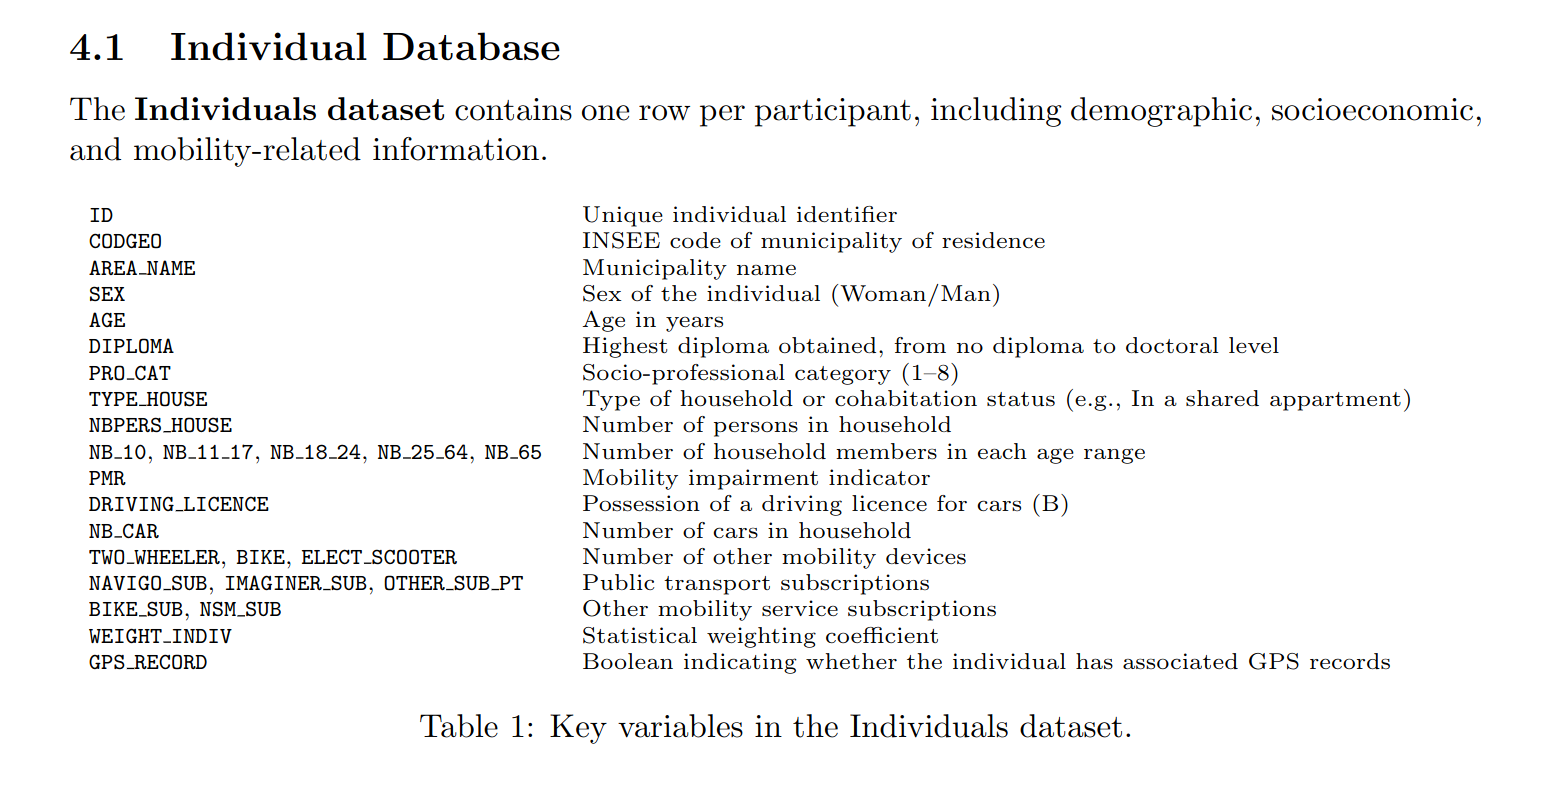

# WHICH AREAS HAS THE MOST TRAFFIC AND WHAT ARE THE AVERAGE TRAFFIC TRENDS ACROSS THE DAY


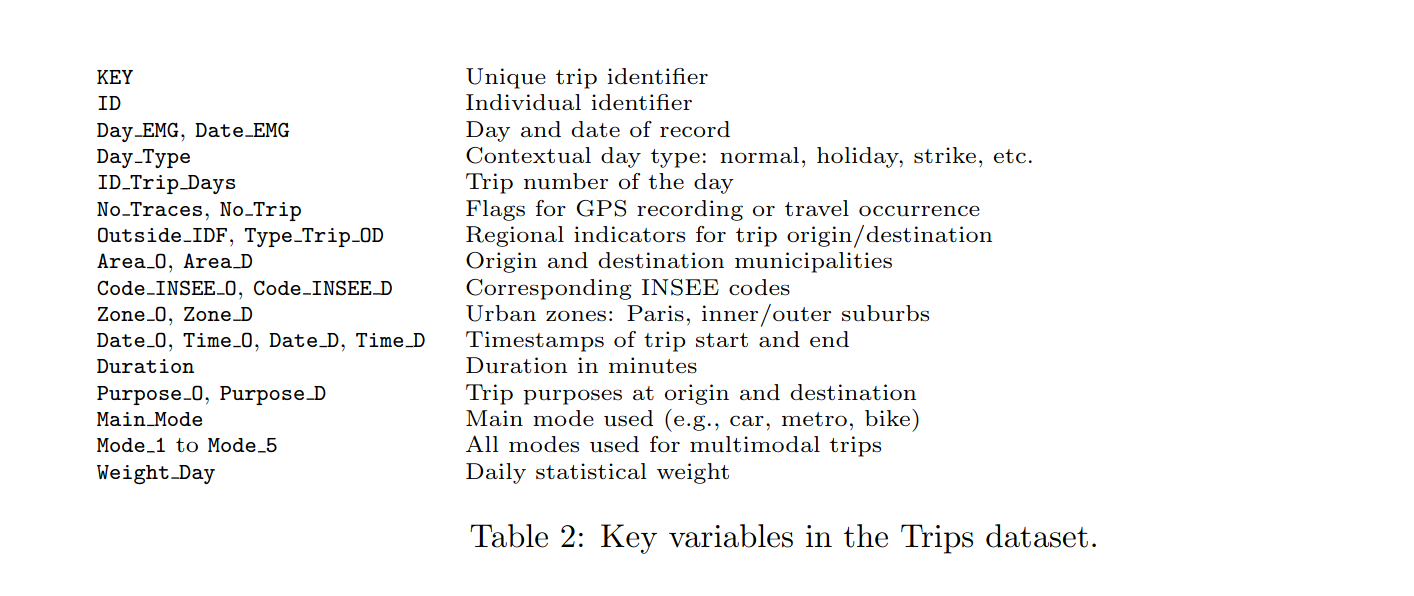

In [4]:
print("individuals dataframe columns: ", individuals_df.columns, "\n")
print("trips dataframe columns: ", trips_df.columns, "\n")
print("common columns between the 2 dataframes: ", set(individuals_df.columns).intersection(set(trips_df.columns)))

individuals dataframe columns:  ['ID', 'CODGEO', 'AREA_NAME', 'SEX', 'AGE', 'DIPLOMA', 'PRO_CAT', 'TYPE_HOUSE', 'NBPERS_HOUSE', 'NB_10', 'NB_11_17', 'NB_18_24', 'NB_25_64', 'NB_65', 'PMR', 'DRIVING_LICENCE', 'NB_CAR', 'TWO_WHEELER', 'BIKE', 'ELECT_SCOOTER', 'NAVIGO_SUB', 'IMAGINER_SUB', 'OTHER_SUB_PT', 'BIKE_SUB', 'NSM_SUB', 'WEIGHT_INDIV', 'GPS_RECORD'] 

trips dataframe columns:  ['KEY', 'ID', 'Day_EMG', 'Date_EMG', 'Day_Type', 'ID_Trip_Days', 'Type_Trip_OD', 'Area_O', 'Area_D', 'Code_INSEE_O', 'Code_INSEE_D', 'Zone_O', 'Zone_D', 'Date_O', 'Time_O', 'Date_D', 'Time_D', 'Duration', 'Purpose_O', 'Purpose_D', 'Main_Mode', 'Mode_1', 'Mode_2', 'Mode_3', 'Mode_4', 'Mode_5', 'Weight_Day'] 

common columns between the 2 dataframes:  {'ID'}


In [5]:
individuals_df.head()

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
str,i64,str,str,i64,str,i64,str,i64,i64,f64,f64,i64,i64,bool,bool,i64,str,str,str,bool,bool,bool,bool,bool,f64,bool
"""10_2978""",78092,"""Bougival""","""Woman""",41,null,4,"""In a couple with child(ren)""",2,1,0.0,0.0,1,0,false,true,2,"""1""","""2""","""0""",false,false,false,false,false,1856.20616,true
"""10_2980""",75120,"""Paris""","""Man""",30,"""5-year-and-above higher educat…",2,"""Living alone""",1,0,0.0,0.0,0,0,false,true,0,"""0""","""0""","""0""",true,false,false,false,false,1375.000372,true
"""10_2981""",91326,"""Juvisy-sur-Orge""","""Man""",38,"""5-year-and-above higher educat…",2,"""In a couple without children""",2,0,0.0,0.0,2,0,false,true,1,"""0""","""1""","""0""",true,false,false,false,false,1231.81299,true
"""10_2982""",91573,"""Saint-Pierre-du-Perray""","""Man""",43,"""3–4-year higher education degr…",2,"""Single parent (divorced / sepa…",1,1,0.0,0.0,0,0,false,true,1,"""0""","""2""","""0""",true,false,false,false,false,426.311616,true
"""10_2984""",78073,"""Bois-d'Arcy""","""Woman""",39,"""5-year-and-above higher educat…",2,"""Living alone""",1,0,0.0,0.0,0,0,false,true,1,"""0""","""1""","""0""",true,false,false,true,false,843.194726,true


In [6]:
trips_df.head()

KEY,ID,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,Code_INSEE_D,Zone_O,Zone_D,Date_O,Time_O,Date_D,Time_D,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64
"""42_0001-monday-44851-PDD""","""42_0001""","""monday""","""2022-10-17""","""Normal""","""No_Trip""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,97.171946
"""42_0001-tuesday-44852-1""","""42_0001""","""tuesday""","""2022-10-18""","""Strike""","""1""","""Internal""","""SAVIGNY-SUR-ORGE""","""SAINT-MAUR-DES-FOSSES""","""91589""","""94068""","""OS""","""IS""","""2022-10-18""","""07:29:00""","""2022-10-18""","""08:41:00""",72.0,"""DEPART_HOME""","""OTHER""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001-tuesday-44852-2""","""42_0001""","""tuesday""","""2022-10-18""","""Strike""","""2""","""Internal""","""SAINT-MAUR-DES-FOSSES""","""SAINTE-GENEVIEVE-DES-BOIS""","""94068""","""91549""","""IS""","""OS""","""2022-10-18""","""10:48:00""","""2022-10-18""","""11:27:00""",39.0,"""OTHER""","""LEISURE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001-tuesday-44852-3""","""42_0001""","""tuesday""","""2022-10-18""","""Strike""","""3""","""Internal""","""SAINTE-GENEVIEVE-DES-BOIS""","""EPINAY-SUR-ORGE""","""91549""","""91216""","""OS""","""OS""","""2022-10-18""","""13:23:00""","""2022-10-18""","""13:40:00""",17.0,"""LEISURE""","""PURCHASE""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337
"""42_0001-tuesday-44852-4""","""42_0001""","""tuesday""","""2022-10-18""","""Strike""","""4""","""Internal""","""EPINAY-SUR-ORGE""","""SAVIGNY-SUR-ORGE""","""91216""","""91589""","""OS""","""OS""","""2022-10-18""","""14:08:00""","""2022-10-18""","""14:14:00""",6.0,"""PURCHASE""","""RETURN_HOME""","""PRIV_CAR_PASSENGER""","""PRIV_CAR_PASSENGER""",null,null,null,null,92.090337


In [7]:
import polars as pl
import math


def plot_violin_all_columns(
        df: pl.DataFrame,
        numeric_only: bool = True,
        ncol: int = 3,
        figure_size: tuple = (14, 8),
):
    """
    Plot violin plots for all columns of a Polars DataFrame using Seaborn.

    Highlights:
    - Violin density (light blue)
    - Median (red)
    - Q1 & Q3 (blue box edges)
    - Whiskers (black)
    - Outliers (red points)
    """

    # 1. Select appropriate columns
    columns = df.select(cs.numeric()).columns if numeric_only else df.columns
    if not columns:
        raise ValueError("No numeric columns found.")

    # 2. Setup the Matplotlib grid
    n_cols_total = len(columns)
    nrow = math.ceil(n_cols_total / ncol)

    # Using layout="constrained" handles spacing beautifully automatically
    fig, axes = plt.subplots(nrow, ncol, figsize=figure_size, layout="constrained")
    axes = [axes] if n_cols_total == 1 else axes.flatten()

    # Convert to pandas for Seaborn (perfectly efficient for plotting)
    plot_df = df.select(columns).to_pandas()

    # 3. Plot each feature
    for i, col in enumerate(columns):
        ax = axes[i]
        col_data = plot_df[col].dropna()

        # Draw the Violin (Density only, inner=None turns off default boxes)
        sns.violinplot(
            y=col_data,
            ax=ax,
            color="#80b1d3",
            inner=None,
            alpha=0.7,
            linewidth=1.2,
        )

        # Overlay a customized Boxplot for Q1/Q3, Median, Whiskers, and Outliers
        sns.boxplot(
            y=col_data,
            ax=ax,
            width=0.15,  # Keep it narrow inside the violin
            boxprops={
                "facecolor": "none",  # Transparent box body
                "edgecolor": "blue",  # Q1 (bottom) and Q3 (top)
                "linewidth": 2,
            },
            medianprops={
                "color": "red",  # Median line
                "linewidth": 2.5,
            },
            whiskerprops={
                "color": "black",  # Whiskers
                "linewidth": 1.5,
            },
            capprops={
                "color": "black",  # Caps on the whiskers
                "linewidth": 1.5,
            },
            flierprops={
                "marker": "o",
                "markerfacecolor": "red",  # Outliers
                "markeredgecolor": "red",
                "markersize": 4,
            }
        )

        # Formatting
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Value")
        ax.set_xlabel("")
        ax.set_xticks([])  # Remove empty x-axis ticks

    # 4. Remove any empty subplots if the grid isn't perfectly filled
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

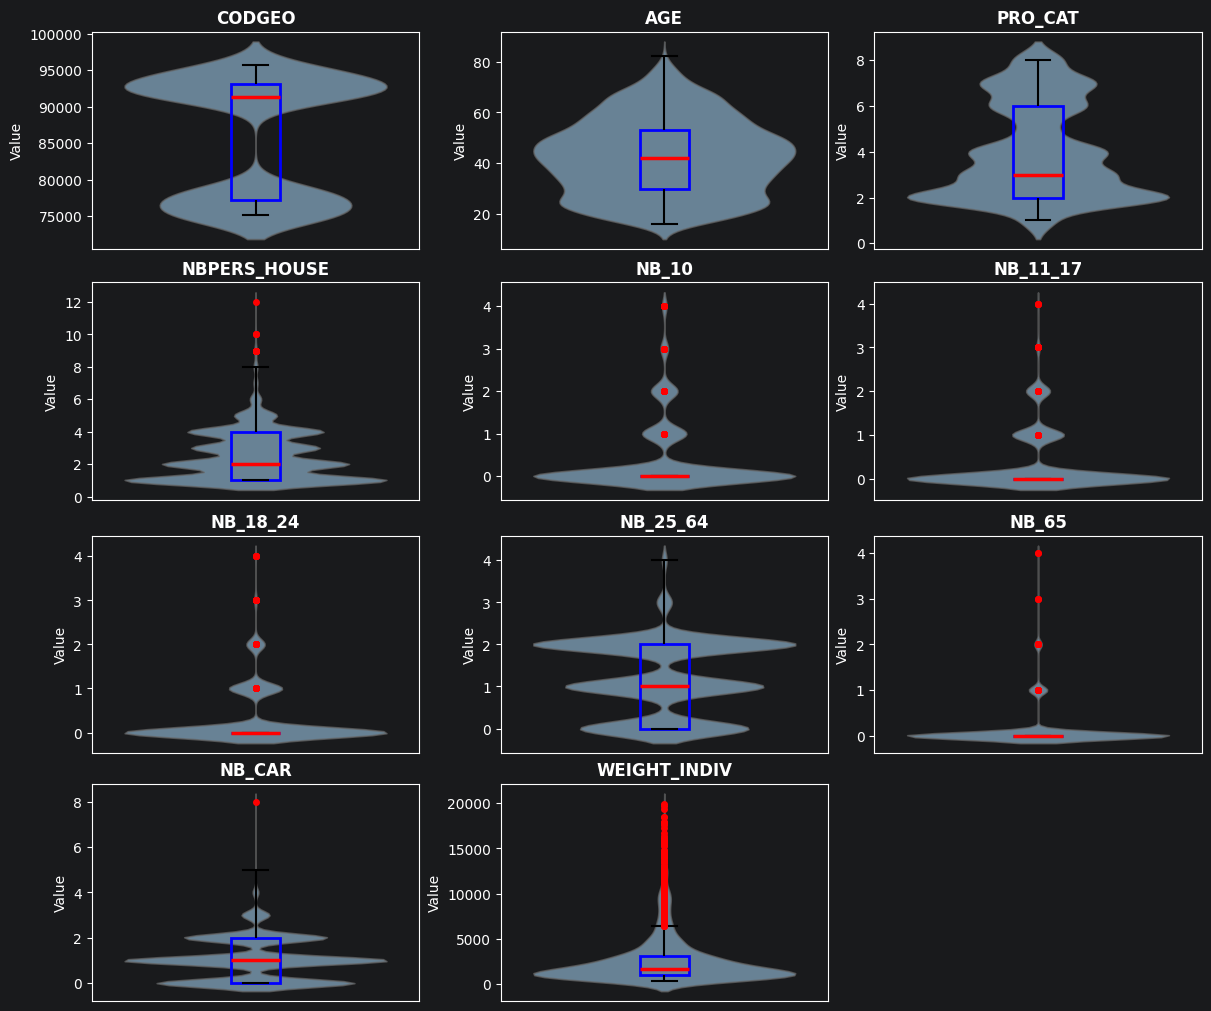

In [8]:
plot_violin_all_columns(individuals_df, ncol=3, figure_size=(12, 10))

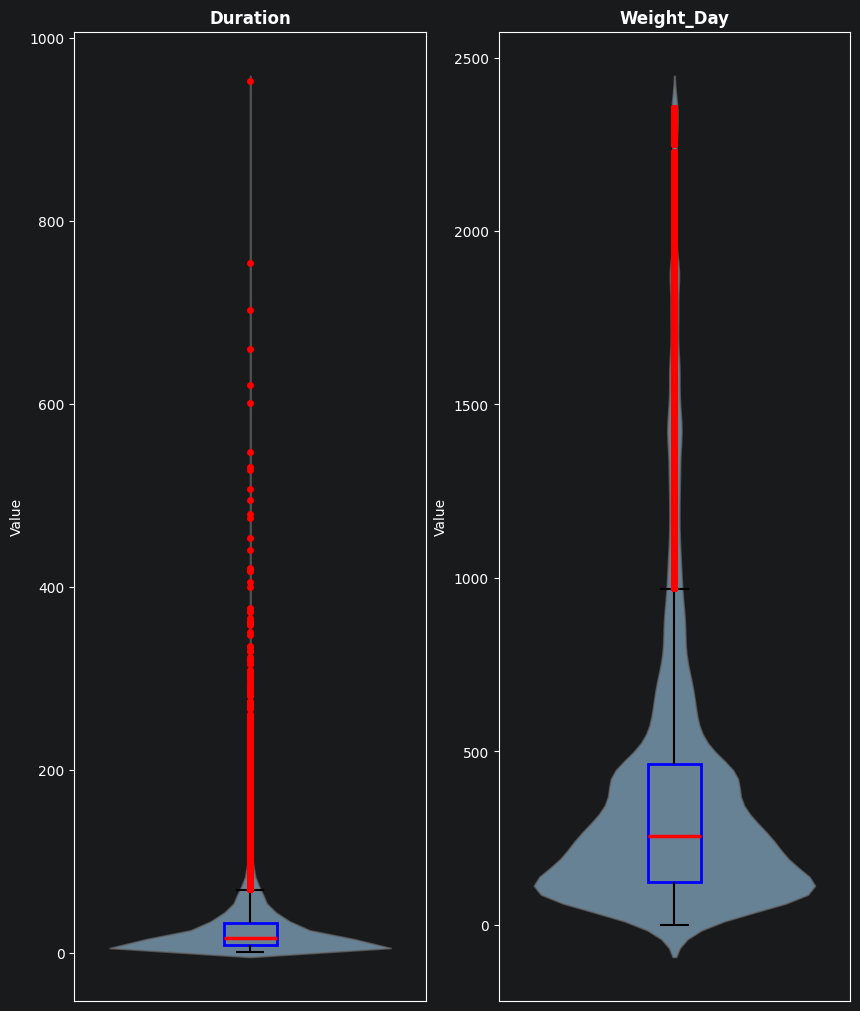

In [9]:
plot_violin_all_columns(trips_df, ncol=3, figure_size=(12, 10))

In [12]:



def test_feature_linearity(
        df: pl.DataFrame,
        sample_size: int = 500,
        diff_threshold: float = 0.15
):
    """
    Tests the linearity assumption for PCA using visual and statistical methods.

    Parameters:
    - df: Polars DataFrame
    - sample_size: Number of rows to sample for the pairplot (keeps plotting fast)
    - diff_threshold: The threshold for the difference between Spearman and Pearson
                      to flag a relationship as potentially non-linear.
    """
    # 1. Isolate numeric data and drop nulls
    numeric_cols = df.select(cs.numeric()).columns
    if len(numeric_cols) < 2:
        raise ValueError("Need at least 2 numeric columns to test relationships.")

    df_clean = df.select(numeric_cols).drop_nulls()

    # 2. Statistical Test: Pearson vs Spearman
    # Convert to pandas for correlation matrices
    pdf = df_clean.to_pandas()

    pearson_corr = pdf.corr(method='pearson')
    spearman_corr = pdf.corr(method='spearman')

    # Calculate absolute difference
    corr_diff = (spearman_corr.abs() - pearson_corr.abs()).abs()

    print("--- Non-Linearity Flags (Spearman vs Pearson Difference) ---")
    flags_found = False

    # Extract upper triangle to avoid duplicate pairs
    upper_tri = corr_diff.where(np.triu(np.ones(corr_diff.shape), k=1).astype(bool))

    for col in upper_tri.columns:
        for row in upper_tri.index:
            diff = upper_tri.loc[row, col]
            if diff > diff_threshold:
                flags_found = True
                print(f"⚠️ {row} vs {col}: Difference = {diff:.3f} "
                      f"(Pearson: {pearson_corr.loc[row, col]:.2f}, "
                      f"Spearman: {spearman_corr.loc[row, col]:.2f})")

    if not flags_found:
        print("✅ No major non-linear monotonic relationships flagged.")

    # 3. Visual Test: Sample data to prevent PairGrid from freezing on large datasets
    if len(pdf) > sample_size:
        print(f"\nSampling {sample_size} rows for the visual pairplot...")
        pdf_sample = pdf.sample(n=sample_size, random_state=42)
    else:
        pdf_sample = pdf

    # Custom mapping function to overlay Linear (Red) and LOWESS (Blue) lines
    def plot_fits(x, y, **kwargs):
        # Suppress rank warnings from numpy polyfit for perfectly flat lines
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', np.RankWarning)
            # Scatter + Linear line
            sns.regplot(
                x=x, y=y, ci=None,
                scatter_kws={'alpha': 0.4, 'color': 'gray', 's': 10},
                line_kws={'color': 'red', 'linewidth': 2}
            )
            # LOWESS (Smooth) line -> Requires statsmodels installed
            sns.regplot(
                x=x, y=y, scatter=False, ci=None, lowess=True,
                line_kws={'color': 'blue', 'linewidth': 2, 'linestyle': '--'}
            )

    print("\nGenerating PairPlot... (Red = Linear, Blue = Smooth/LOWESS)")

    # Create PairGrid
    g = sns.PairGrid(pdf_sample, diag_sharey=False)
    g.map_lower(plot_fits)
    g.map_diag(sns.histplot, kde=True, color="#80b1d3")

    # Hide the upper triangle to keep it clean
    for i, j in zip(*np.triu_indices_from(g.axes, 1)):
        g.axes[i, j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [11]:
test_feature_linearity(individuals_df, sample_size=individuals_df.shape[0], diff_threshold=0.15)

--- Non-Linearity Flags (Spearman vs Pearson Difference) ---


NameError: name 'np' is not defined

In [ ]:



def plot_pairwise_residuals(
        df: pl.DataFrame,
        sample_size: int = 500
):
    """
    Creates a grid of residual plots for every numeric feature pair to check
    for linearity and homoscedasticity before applying PCA.
    """
    # 1. Isolate numeric data and drop nulls
    numeric_cols = df.select(cs.numeric()).columns
    if len(numeric_cols) < 2:
        raise ValueError("Need at least 2 numeric columns for pairwise plots.")

    df_clean = df.select(numeric_cols).drop_nulls()
    pdf = df_clean.to_pandas()

    # 2. Sample data to keep plotting fast and scatter plots readable
    if len(pdf) > sample_size:
        print(f"Sampling {sample_size} rows to prevent overplotting...")
        pdf_sample = pdf.sample(n=sample_size, random_state=42)
    else:
        pdf_sample = pdf

    # 3. Custom plotting function for the lower triangle
    def custom_residplot(x, y, **kwargs):
        # Suppress potential statsmodels/numpy warnings during LOWESS fitting
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            # sns.residplot automatically fits y ~ x and plots the residuals
            sns.residplot(
                x=x, y=y,
                lowess=False,  # Adds a smooth curve to track the residual trend
                scatter_kws={'alpha': 0.4, 'color': 'gray', 's': 15},
                line_kws={'color': 'red', 'linewidth': 2}
            )

    print("Generating Pairwise Residual Plots...")

    # 4. Build the grid
    g = sns.PairGrid(pdf_sample, diag_sharey=False)
    g.map_lower(custom_residplot)
    g.map_diag(sns.histplot, kde=True, color="#80b1d3")

    # Hide the upper triangle to keep the visual field clean
    for i, j in zip(*np.triu_indices_from(g.axes, 1)):
        g.axes[i, j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_pairwise_residuals(individuals_df, sample_size=individuals_df.shape[0])

In [17]:
import polars as pl
import numpy as np

# Calculate mean age before the transformation pipeline
mean_age = individuals_df["AGE"].mean()

cols_to_drop = ['NB_10', 'NB_11_17', 'NB_18_24', 'NB_25_64', 'NB_65', 'ID', 'CODGEO']

individuals_transformed_df = (
    individuals_df
    # ---------------------------------------------------------
    # PASS 1: Ordinal/Binary Encodings
    # ---------------------------------------------------------
    .with_columns(
        [
            pl.col("SEX").replace({"Man": 0, "Woman": 1}, return_dtype=pl.Int8),
            pl.col("DIPLOMA")
            .replace(
                {
                    "5-year-and-above higher education degree: Master's 2, DEA, DESS, Grande École Diploma, Doctorate, etc.": 6,
                    "3–4-year higher education degree: Licence, Professional Licence, Master 1, or equivalent": 5,
                    "Upper secondary diploma (Baccalauréat) or equivalent": 4,
                    "Vocational certificate (CAP, BEP) or equivalent": 3,
                    "Lower secondary certificate (Brevet) or equivalent": 2,
                    "No diploma": 1,
                },
                default=0,
            )
            .cast(pl.Int8),

            # Ensure these are cast to int after replacing the string "4+"
            pl.col("TWO_WHEELER").replace({"4+": 4}, return_dtype=pl.Int8),
            pl.col("BIKE").replace({"4+": 4}, return_dtype=pl.Int8),
            pl.col("ELECT_SCOOTER").replace({"4+": 4}, return_dtype=pl.Int8),

            # Transit subscription flags are inverted
            pl.col("NAVIGO_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
            pl.col("IMAGINER_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
            pl.col("OTHER_SUB_PT").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
            pl.col("BIKE_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
            pl.col("NSM_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
        ]
    )
    # ---------------------------------------------------------
    # PASS 2: Mathematical Transformations (Overwriting originals)
    # ---------------------------------------------------------
    .with_columns(
        [
            # Age
            ((pl.col("AGE") - mean_age).abs() + 1).log().alias("AGE"),

            # Resource indicators (Polars .log() defaults to natural log (base e))
            (1 / ((pl.col("NB_CAR") + 1).log() + 1)).alias("NB_CAR"),
            (1 / ((pl.col("TWO_WHEELER") + 1).log() + 1)).alias("TWO_WHEELER"),
            (1 / ((pl.col("BIKE") + 1).log() + 1)).alias("BIKE"),
            (1 / ((pl.col("ELECT_SCOOTER") + 1).log() + 1)).alias("ELECT_SCOOTER"),
            (1 / ((pl.col("DIPLOMA") + 1).log() + 1)).alias("DIPLOMA"),

            # Household size
            pl.col("NBPERS_HOUSE").log().alias("NBPERS_HOUSE"),
        ]
    )
    # ---------------------------------------------------------
    # PASS 3: Drop unwanted features
    # ---------------------------------------------------------
    .drop(cols_to_drop)
)

/tmp/ipykernel_65128/527280385.py:16: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("SEX").replace({"Man": 0, "Woman": 1}, return_dtype=pl.Int8),
/tmp/ipykernel_65128/527280385.py:18: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  .replace(
/tmp/ipykernel_65128/527280385.py:32: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing values.
(Deprecated in version 1.0.0)
  pl.col("TWO_WHEELER").replace({"4+": 4}, return_dtype=pl.Int8),
/tmp/ipykernel_65128/527280385.py:33: DeprecationWarning: the `return_dtype` parameter for `replace` is deprecated. Use `replace_strict` instead to set a return data type while replacing val

Generating Pairwise Residual Plots...


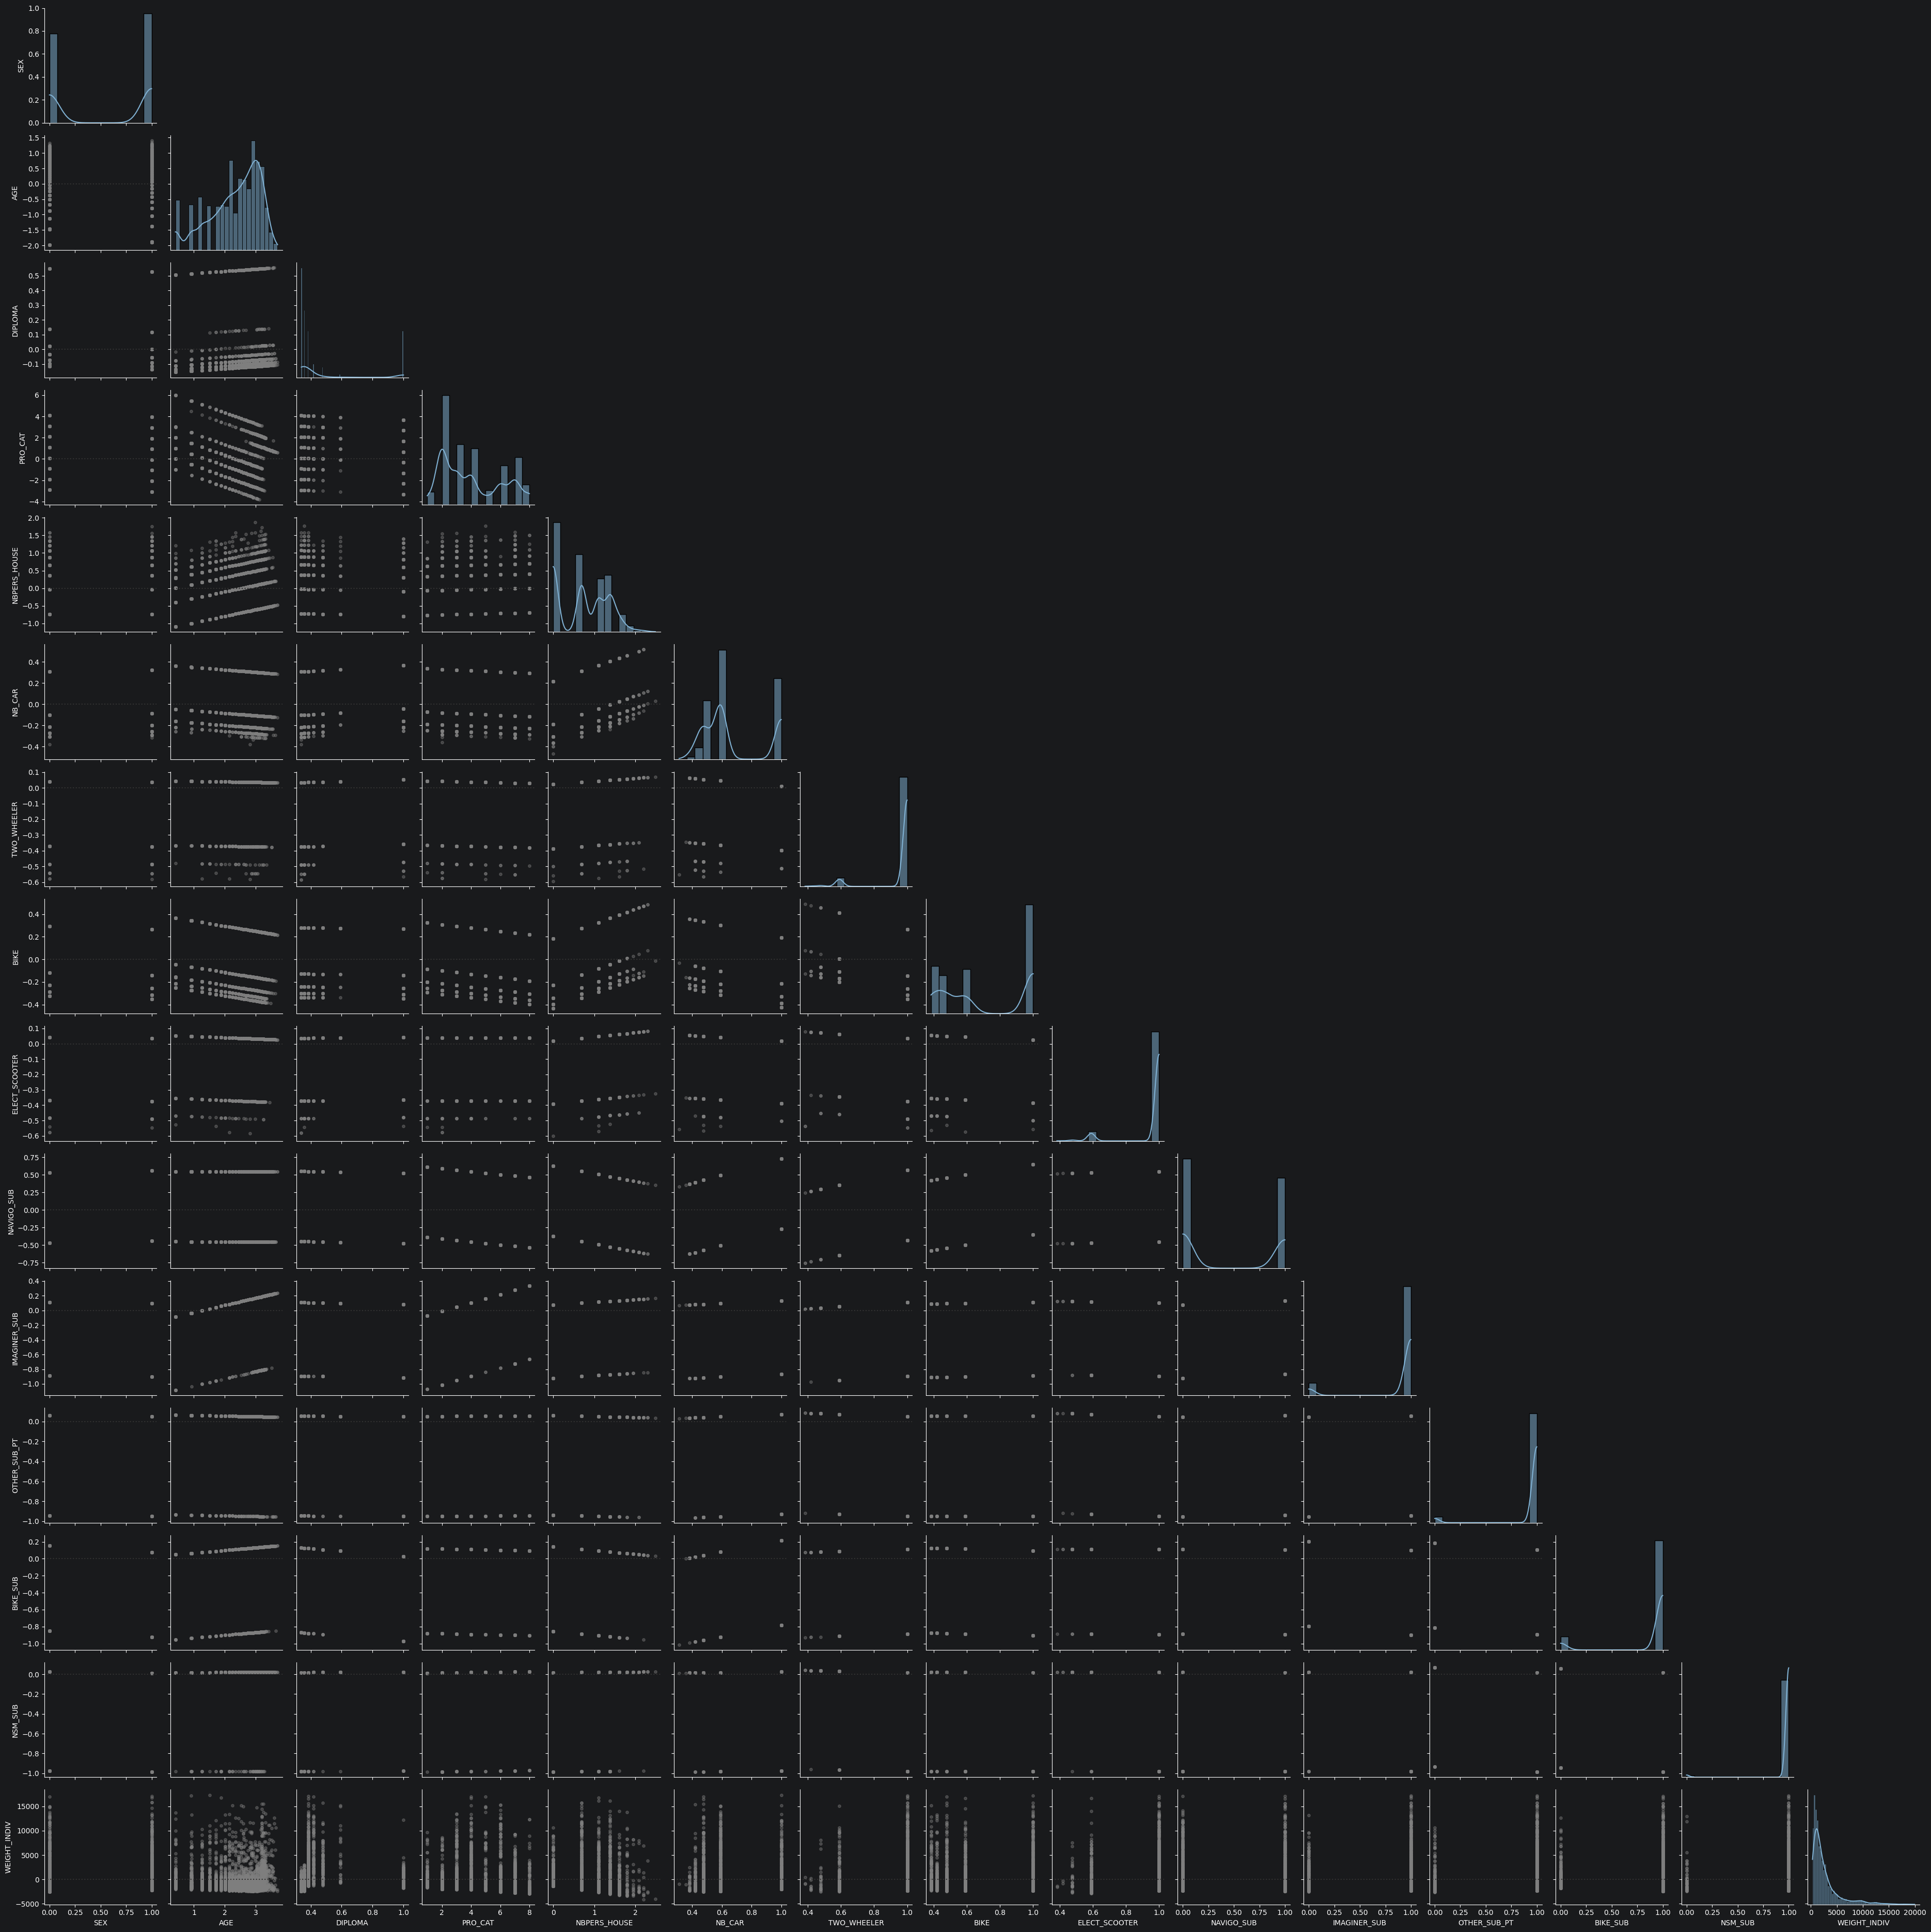

In [18]:
plot_pairwise_residuals(individuals_transformed_df, sample_size=individuals_transformed_df.shape[0])

 check if tehre's multi collinearity between theese variables: 'NB_10', 'NB_11_17', 'NB_18_24', 'NB_25_64', 'NB_65' and NBPERS_HOUSE, if so discard the subfeatures

Phase 2: Expanding the EDA

Violin plots and residual grids are excellent for understanding distribution and variance, but they miss two critical dimensions needed for urban data science: Space and Overlap.

Here is what you need to do next in your EDA:

    Spatial EDA (Geospatial Mapping): CODGEO is not just a categorical grouping; it is a physical location. You need to map these variables. Build choropleth maps (using Geopandas, for instance) of your key demographic features. Vulnerability is rarely randomly distributed; it clusters. You need to verify if your extreme values (outliers) are geographically concentrated in specific municipalities.

    Multicollinearity Checks (Spearman Matrix): You need to check how these features interact with each other. If NBPERS_HOUSE (total people) and NB_11_17 (teenagers) are perfectly correlated, feeding both into FAMD will result in "double-counting" that demographic factor in the final index. Run a Spearman rank correlation matrix and drop or combine highly collinear features.

    Missing Data Topography: Check the exact nature of any null values. Do not just impute them with the mean. In mobility data, a missing value for public transport subscriptions (NAVIGO_SUB) often implies a "No," not an average. FAMD and autoencoders are highly sensitive to how missingness is handled.

Before you start writing the transformation pipeline, how are you currently defining "vulnerability" in the context of your simulation—are you focusing more on socio-economic limitations (like PRO_CAT), physical mobility constraints (like PMR and NB_CAR), or a specific combination of both?